# Modularity Maximization vs. Stochastic Block Model on the Left oviIN Inputs

### Dataset: FAFB FlyWire v783

This notebook asks: **does the community structure in the oviIN input subconnectome depend on the method used to detect it?** If two independent methods — one based on modularity optimization and one based on statistical inference — find the same communities, the structure is robust and likely reflects real biology rather than a methodological artifact.

**Section 0** — Environment setup (run once, restart, then skip).

**Section 1** — Load FAFB data, identify the left oviIN, extract its input subconnectome, and fetch synapse coordinates.

**Section 2** — Modularity maximization using RenEEL (the lab's established method).

**Section 3** — Degree-corrected Stochastic Block Model using graspologic.

**Section 4** — Pairwise Jaccard similarity comparing the two partitions.

**Section 5** — Reproduce the full analysis using `modularity_sbm_pipeline.py`.

*Source: Gutierrez Lab, Barnard College. Data from FlyWire (Dorkenwald et al., 2024).*

---
# Section 0: Environment Setup

Graspologic requires `numpy < 2.0`. Installing pinned versions before all other imports prevents dependency conflicts. **Run this cell once, then restart the runtime (Runtime → Restart runtime) and skip directly to Section 1.**

In [1]:
# ──────────────────────────────────────────────────────────
# CELL 0.1 — Install pinned dependencies (run once, then restart)
# ──────────────────────────────────────────────────────────
!pip install "numpy<2.0,>=1.24" "pandas>=1.5,<3.0" graspologic caveclient -q
print("Dependencies installed. Restart runtime now, then skip to Section 1.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.4/93.4 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.1/45.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 917.8/917.8 kB 54.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.6/364.6 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.3/192.3 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 124.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.

---
# Section 1: Data Loading

The goal of this section is to load the FAFB FlyWire v783 dataset, identify the left oviposition inhibitory neuron (oviIN), and extract the subconnectome formed by its presynaptic partners — all the neurons that provide input to the oviIN and all the connections among them. This subconnectome is the network whose community structure we want to analyze.

We also fetch per-synapse xyz coordinates from the FlyWire synapse table via `caveclient`. These coordinates tell us *where* on the oviIN dendrite each synapse lands, allowing us to ask whether neurons in the same community tend to synapse onto the same region of the dendrite.

## 1.1 Imports

In [1]:
# ──────────────────────────────────────────────────────────
# CELL 1.1 — Imports
# ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

print("Imports complete.")

Mounted at /content/drive
Imports complete.


## 1.2 Load FAFB tables from Drive

Three CSV files are needed from the FAFB data directory: the connections edge list (who connects to whom and with how many synapses), the cell type annotations (to find neurons labeled "oviIN"), and the classification table (to determine left vs. right side).

In [2]:
# ──────────────────────────────────────────────────────────
# CELL 1.2 — Load FAFB tables
# ──────────────────────────────────────────────────────────
DATA_DIR = '/content/drive/MyDrive/Barnard Drosophila/FAFB/Data_Files/'

connections = pd.read_csv(DATA_DIR + 'connections_princeton.csv')
print(f"connections_princeton.csv: {len(connections):,} rows")

cell_types = pd.read_csv(DATA_DIR + 'consolidated_cell_types.csv')
print(f"consolidated_cell_types.csv: {len(cell_types):,} rows")

classification = pd.read_csv(DATA_DIR + 'classification.csv')
print(f"classification.csv: {len(classification):,} rows")

# ── Sanity check: expected column schemas ──
expected_conn_cols = ['pre_root_id', 'post_root_id', 'neuropil', 'syn_count', 'nt_type']
assert list(connections.columns) == expected_conn_cols, \
    f"FAIL: connections columns {connections.columns.tolist()} != {expected_conn_cols}"
assert 'primary_type' in cell_types.columns, \
    f"FAIL: 'primary_type' not in cell_types: {cell_types.columns.tolist()}"
assert 'side' in classification.columns, \
    f"FAIL: 'side' not in classification: {classification.columns.tolist()}"
print("\n✓ Column schema checks passed.")

connections_princeton.csv: 5,342,446 rows
consolidated_cell_types.csv: 138,327 rows
classification.csv: 139,255 rows

✓ Column schema checks passed.


## 1.3 Identify the left oviIN

In [3]:
# ──────────────────────────────────────────────────────────
# CELL 1.3 — Identify the left oviIN
# ──────────────────────────────────────────────────────────
ovi = cell_types[cell_types['primary_type'] == 'oviIN']
ovi_full = ovi.merge(classification[['root_id', 'side']], on='root_id', how='left')
print("oviIN neurons in FAFB:")
print(ovi_full[['root_id', 'primary_type', 'side']].to_string(index=False))

oviIN_left_id = ovi_full.loc[ovi_full['side'] == 'left', 'root_id'].iloc[0]
print(f"\nLeft oviIN root_id: {oviIN_left_id}")

# ── Sanity check ──
n_left = (ovi_full['side'] == 'left').sum()
assert n_left == 1, f"FAIL: expected 1 left oviIN, found {n_left}"
print(f"✓ Exactly 1 left oviIN found.")

oviIN neurons in FAFB:
           root_id primary_type  side
720575940628360506        oviIN  left
720575940625741287        oviIN right

Left oviIN root_id: 720575940628360506
✓ Exactly 1 left oviIN found.


## 1.4 Extract the input subconnectome

The input subconnectome consists of all neurons presynaptic to the left oviIN (its "inputs"), plus all directed connections among those input neurons. This is the network whose community structure we analyze — not just the direct connections to the oviIN, but the full pattern of connectivity among its input population.

In [4]:
# ──────────────────────────────────────────────────────────
# CELL 1.4 — Extract input subconnectome
# ──────────────────────────────────────────────────────────
inputs_to_ovi = connections[connections['post_root_id'] == oviIN_left_id]
input_ids = set(inputs_to_ovi['pre_root_id'].unique())
print(f"Presynaptic partners to left oviIN: {len(input_ids):,}")
print(f"Total synapses onto left oviIN: {inputs_to_ovi['syn_count'].sum():,}")

subconn = connections[
    connections['pre_root_id'].isin(input_ids) &
    connections['post_root_id'].isin(input_ids)
].copy()
print(f"\nSubconnectome edges: {len(subconn):,}")
print(f"Subconnectome total weight: {subconn['syn_count'].sum():,}")

# ── Sanity checks ──
assert len(input_ids) > 0, "FAIL: no presynaptic partners found"
assert len(subconn) > 0, "FAIL: no edges in subconnectome"
assert subconn['syn_count'].min() > 0, "FAIL: zero-weight edges found"
assert subconn['pre_root_id'].isin(input_ids).all(), "FAIL: pre_root_id outside input set"
assert subconn['post_root_id'].isin(input_ids).all(), "FAIL: post_root_id outside input set"
print(f"\n✓ Subconnectome integrity checks passed.")

Presynaptic partners to left oviIN: 243
Total synapses onto left oviIN: 2,913

Subconnectome edges: 2,542
Subconnectome total weight: 23,658

✓ Subconnectome integrity checks passed.


## 1.5 Build integer-indexed edge list

Both community detection methods need integer node IDs (0 to N-1). We create a bidirectional mapping between FlyWire root_ids and integers. This also avoids problems with 18-digit root_ids overflowing buffers in the C-based RenEEL binary.

In [5]:
# ──────────────────────────────────────────────────────────
# CELL 1.5 — Integer node mapping and edge list
# ──────────────────────────────────────────────────────────
all_nodes = sorted(input_ids)
node_to_idx = {nid: i for i, nid in enumerate(all_nodes)}
idx_to_node = {i: nid for nid, i in node_to_idx.items()}
n_nodes = len(all_nodes)

edges_df = subconn[['pre_root_id', 'post_root_id', 'syn_count']].copy()
edges_df['src'] = edges_df['pre_root_id'].map(node_to_idx)
edges_df['tgt'] = edges_df['post_root_id'].map(node_to_idx)
edges_df = edges_df.dropna(subset=['src', 'tgt'])
edges_df['src'] = edges_df['src'].astype(int)
edges_df['tgt'] = edges_df['tgt'].astype(int)

print(f"Subconnectome: {n_nodes} nodes, {len(edges_df):,} directed edges")
print(edges_df[['src', 'tgt', 'syn_count']].head())

# ── Sanity checks ──
assert edges_df['src'].between(0, n_nodes - 1).all(), "FAIL: src out of range"
assert edges_df['tgt'].between(0, n_nodes - 1).all(), "FAIL: tgt out of range"
assert len(edges_df) == len(subconn), \
    f"FAIL: edge count changed after mapping ({len(edges_df)} vs {len(subconn)})"
print(f"\n✓ Edge list mapping checks passed.")

Subconnectome: 243 nodes, 2,542 directed edges
        src  tgt  syn_count
169494  241    0          1
170809  105   29        119
172915  144   77         50
173378  135  141          3
174008  126  129          9

✓ Edge list mapping checks passed.


## 1.6 Fetch synapse coordinates from caveclient

Per-synapse xyz positions are not in the Drive CSVs. We use `caveclient` to query the `synapses_nt_v1` table for all synapses where the postsynaptic partner is the left oviIN. Each synapse record includes `post_pt_position` — the [x, y, z] coordinates (in nanometers) of where the synapse lands on the oviIN dendrite. These coordinates are what we will color by community assignment in the skeleton plots.

Note: the synapse table is unthresholded and includes many more presynaptic partners than the connections table, which applies a minimum synapse count filter. All partners from the connections table should be present in the synapse table.

In [6]:
# ──────────────────────────────────────────────────────────
# CELL 1.6a — Connect to caveclient
# ──────────────────────────────────────────────────────────
from caveclient import CAVEclient
from google.colab import userdata

cave_token = userdata.get('CAVE_TOKEN')
client = CAVEclient('flywire_fafb_public', auth_token=cave_token,
                     server_address='https://global.daf-apis.com')
client.materialize.version = 783
print(f"Connected to CAVE, materialization version: {client.materialize.version}")

Connected to CAVE, materialization version: 783


In [7]:
# ──────────────────────────────────────────────────────────
# CELL 1.6b — Fetch synapses onto left oviIN (may take 1-2 min)
# ──────────────────────────────────────────────────────────
print("Fetching synapses onto left oviIN...")
ovi_syns = client.materialize.query_table(
    'synapses_nt_v1',
    filter_equal_dict={'post_pt_root_id': oviIN_left_id}
)
print(f"Synapses onto left oviIN: {len(ovi_syns):,}")

ovi_syns['post_x'] = ovi_syns['post_pt_position'].apply(lambda p: p[0])
ovi_syns['post_y'] = ovi_syns['post_pt_position'].apply(lambda p: p[1])
ovi_syns['post_z'] = ovi_syns['post_pt_position'].apply(lambda p: p[2])

print(f"Coordinate ranges (nm):")
print(f"  X: [{ovi_syns['post_x'].min():,}, {ovi_syns['post_x'].max():,}]")
print(f"  Y: [{ovi_syns['post_y'].min():,}, {ovi_syns['post_y'].max():,}]")
print(f"  Z: [{ovi_syns['post_z'].min():,}, {ovi_syns['post_z'].max():,}]")
print(f"Unique presynaptic partners in synapse table: {ovi_syns['pre_pt_root_id'].nunique():,}")

# ── Sanity checks ──
assert len(ovi_syns) > 0, "FAIL: no synapses returned"
assert ovi_syns['post_pt_root_id'].nunique() == 1, "FAIL: multiple post neurons"
assert ovi_syns[['post_x', 'post_y', 'post_z']].notna().all().all(), "FAIL: NaN coordinates"
print(f"\n✓ Synapse data checks passed.")

Fetching synapses onto left oviIN...
Synapses onto left oviIN: 9,700
Coordinate ranges (nm):
  X: [421,020, 589,280]
  Y: [94,904, 306,896]
  Z: [27,600, 177,760]
Unique presynaptic partners in synapse table: 2,007

✓ Synapse data checks passed.


### Cross-check: synapse table vs connections table

In [8]:
# ──────────────────────────────────────────────────────────
# CELL 1.6c — Verify overlap between synapse and connection tables
# ──────────────────────────────────────────────────────────
syn_pre_ids = set(ovi_syns['pre_pt_root_id'].unique())
conn_pre_ids = input_ids
overlap = syn_pre_ids & conn_pre_ids

print(f"Presynaptic IDs in synapse table: {len(syn_pre_ids):,}")
print(f"Presynaptic IDs in connections table: {len(conn_pre_ids):,}")
print(f"Overlap: {len(overlap):,}")
print(f"Only in synapse table (below threshold): {len(syn_pre_ids - conn_pre_ids):,}")
print(f"Only in connections table: {len(conn_pre_ids - syn_pre_ids):,}")
print(f"Overlap fraction: {len(overlap)/len(conn_pre_ids):.1%}")

# ── Sanity check ──
assert conn_pre_ids - syn_pre_ids == set(), \
    f"FAIL: {len(conn_pre_ids - syn_pre_ids)} connection partners missing from synapses"
print(f"\n✓ All connection partners present in synapse table.")

Presynaptic IDs in synapse table: 2,007
Presynaptic IDs in connections table: 243
Overlap: 243
Only in synapse table (below threshold): 1,764
Only in connections table: 0
Overlap fraction: 100.0%

✓ All connection partners present in synapse table.


---
# Section 2: Modularity Maximization (RenEEL)

Modularity maximization partitions a network into communities by maximizing Q — the fraction of within-community edges minus what would be expected if edges were distributed randomly while preserving each node's degree. Q ranges from -0.5 to 1; values above ~0.3 indicate meaningful community structure.

RenEEL is a spectral method that maintains an ensemble of candidate partitions and iteratively refines them. It was used in the lab's published analysis of oviIN_R inputs in the Hemibrain (Weber Langstaff et al., 2025). The degree-preserving null model is important: it means communities are defined as groups of neurons that connect to each other *more than expected given their individual synapse counts*, not just groups that are densely connected. This controls for the trivial observation that high-degree neurons tend to connect to everything.

We use the lab's `gcm_script.py` pipeline at default resolution (chi=0). The pipeline has three stages:
1. `format_edgelist.py` — renumbers nodes consecutively and creates a key file for mapping back.
2. `work.sh` — preprocesses the edge list (sorting, cleaning, computing node degrees).
3. `a.out` — runs RenEEL. Requires 6 arguments: `krg copy1 copy2 seed chi filename`.

## 2.1 Set up GCM pipeline

In [9]:
# ──────────────────────────────────────────────────────────
# CELL 2.1 — Download pipeline files and compile a.out
# ──────────────────────────────────────────────────────────
import subprocess, sys, os
os.chdir('/content')

pipeline_files = {
    'gcm_script.py':      'https://raw.githubusercontent.com/Gutierrez-lab/oviIN-inputs/main/gcm_pipeline/gcm_script.py',
    'format_edgelist.py': 'https://raw.githubusercontent.com/Gutierrez-lab/oviIN-inputs/main/gcm_pipeline/format_edgelist.py',
    'work.sh':            'https://raw.githubusercontent.com/Gutierrez-lab/oviIN-inputs/main/gcm_pipeline/work.sh',
}

for fname, url in pipeline_files.items():
    if not os.path.exists(fname):
        subprocess.run(["wget", "-q", url, "-O", fname], check=True)
        print(f"Downloaded {fname}")
    else:
        print(f"  {fname} already exists, skipping")

subprocess.run(["chmod", "+x", "work.sh"], check=True)

# Compile a.out with FORTIFY_SOURCE disabled — Colab's newer glibc triggers
# buffer overflow protections on the fixed-size char arrays in main.c.
# This is safe because we control all inputs to the binary.
if not os.path.exists("generalized-modularity-density"):
    subprocess.run(["git", "clone",
                    "https://github.com/prameshsingh/generalized-modularity-density.git"],
                   check=True, capture_output=True)

subprocess.run([
    "gcc", "-O3",
    "-U_FORTIFY_SOURCE", "-D_FORTIFY_SOURCE=0", "-fno-stack-protector",
    "generalized-modularity-density/main.c",
    "generalized-modularity-density/help.c",
    "generalized-modularity-density/rg.c",
    "-lm", "-fopenmp", "-o", "a.out"
], check=True)
subprocess.run(["chmod", "+x", "a.out"], check=True)
print("a.out compiled (with FORTIFY_SOURCE disabled for Colab compatibility)")

sys.path.insert(0, os.getcwd())
from gcm_script import run_format_script

# ── Sanity check ──
assert os.path.exists('a.out'), "FAIL: a.out not compiled"
assert os.path.exists('gcm_script.py'), "FAIL: gcm_script.py missing"
assert os.path.exists('work.sh'), "FAIL: work.sh missing"
print("\n✓ GCM pipeline ready.")

Downloaded gcm_script.py
Downloaded format_edgelist.py
Downloaded work.sh
a.out compiled (with FORTIFY_SOURCE disabled for Colab compatibility)

✓ GCM pipeline ready.


## 2.2 Prepare undirected edge list

RenEEL operates on undirected graphs. We symmetrize the directed subconnectome by summing weights in both directions for each pair of neurons, then remove self-loops.

In [10]:
# ──────────────────────────────────────────────────────────
# CELL 2.2 — Symmetrize edge list for RenEEL
# ──────────────────────────────────────────────────────────
el = edges_df[['src', 'tgt', 'syn_count']].copy()
el_rev = el.rename(columns={'src': 'tgt', 'tgt': 'src'})
el_both = pd.concat([el, el_rev], ignore_index=True)
el_und = el_both.groupby(['src', 'tgt'], as_index=False)['syn_count'].sum()
el_und = el_und[el_und['src'] != el_und['tgt']]

print(f"Undirected edge list: {len(el_und):,} edges")
print(el_und.head())

# ── Sanity check ──
assert len(el_und) > 0, "FAIL: empty undirected edge list"
assert (el_und['syn_count'] > 0).all(), "FAIL: zero-weight undirected edges"
n_self = (el_und['src'] == el_und['tgt']).sum()
assert n_self == 0, f"FAIL: {n_self} self-loops remain"
print(f"\n✓ Undirected edge list checks passed.")

Undirected edge list: 2,260 edges
   src  tgt  syn_count
0    0   20          5
1    0  129         19
2    0  135          8
3    0  241         19
4    1   70         12

✓ Undirected edge list checks passed.


## 2.3 Run RenEEL

In [11]:
# ──────────────────────────────────────────────────────────
# CELL 2.3 — Run format_edgelist -> work.sh -> a.out (RenEEL)
# ──────────────────────────────────────────────────────────
import re
os.chdir('/content')

el_und.to_csv('/content/ovi_left_edges', sep=' ', header=False, index=False)
print("Saved edge list: /content/ovi_left_edges")

# Step 1: format_edgelist (renumbers nodes, creates key file)
run_format_script('/content/ovi_left_edges')
print("format_edgelist done")

# Step 2: work.sh (preprocess: sort, clean, compute degrees)
result_ws = subprocess.run(
    ['bash', 'work.sh', 'ovi_left_edges_formatted'],
    capture_output=True, text=True, timeout=120, cwd='/content'
)
print(f"work.sh: {result_ws.stdout.strip()}")

# Step 3: a.out with 6 required arguments
# krg=2, copy1=5, copy2=2, seed=12345, chi=0.0, filename
result_ao = subprocess.run(
    ['./a.out', '2', '5', '2', '12345', '0.0', 'ovi_left_edges_formatted'],
    capture_output=True, text=True, timeout=300, cwd='/content'
)
print(f"\na.out return code: {result_ao.returncode}")
print(f"a.out output (last 500 chars):\n{result_ao.stdout[-500:]}")
if result_ao.stderr:
    print(f"a.out stderr: {result_ao.stderr[:300]}")

# Parse Q value
reneel_q = None
for line in result_ao.stdout.split('\n'):
    match = re.search(r'Qfinal=([0-9.]+)', line)
    if match:
        reneel_q = float(match.group(1))
        break
print(f"\nQ value: {reneel_q}")

# ── Sanity checks ──
assert result_ao.returncode == 0, f"FAIL: a.out exited with code {result_ao.returncode}"
assert os.path.exists('/content/partition_ovi_left_edges_formatted'), \
    "FAIL: partition file not created"
assert reneel_q is not None, "FAIL: could not parse Q value from a.out output"
assert 0 < reneel_q < 1, f"FAIL: Q value {reneel_q} outside expected range (0, 1)"
print(f"✓ RenEEL completed successfully.")

Saved edge list: /content/ovi_left_edges
format_edgelist done
work.sh: edges=1130
nodes=232

a.out return code: 0
a.out output (last 500 chars):
5
22:size=9,ensem=5,0.472094,0.472094
reducing time: 0.000005
RG time: 0.000037
update ensemble time: 0.000005
23:size=9,ensem=4,0.472094,0.472094
reducing time: 0.000005
RG time: 0.000036
update ensemble time: 0.000005
24:size=9,ensem=3,0.472094,0.472094
reducing time: 0.000005
RG time: 0.000037
update ensemble time: 0.000006
25:size=9,ensem=2,0.472094,0.472094
reducing time: 0.000005
RG time: 0.000036
update ensemble time: 0.000005
rest time=0.007784
real walltime=0
9	0.472094
Qfinal=0.472094


Q value: 0.472094
✓ RenEEL completed successfully.


## 2.4 Read partition and map to root_ids

The partition file contains one module label per node in the order used by `format_edgelist.py`. The key file maps these formatted IDs back to our original integer node IDs, which in turn map to FlyWire root_ids via `idx_to_node`.

Some nodes may be absent from the partition if they had no undirected edges (isolated nodes dropped during `work.sh` preprocessing).

In [12]:
# ──────────────────────────────────────────────────────────
# CELL 2.4 — Read partition, map to root_ids
# ──────────────────────────────────────────────────────────
partition_raw = pd.read_csv('/content/partition_ovi_left_edges_formatted',
                            sep='\s+', header=None, names=['module'])
key_df = pd.read_csv('/content/ovi_left_edges_key',
                     sep='\s+', header=None,
                     names=['formatted_id', 'original_id'])

reneel_partition = pd.DataFrame({
    'formatted_id': range(len(partition_raw)),
    'module': partition_raw['module'].values,
    'node_id': key_df['original_id'].values
})
reneel_partition['root_id'] = reneel_partition['node_id'].map(idx_to_node)

n_modules = reneel_partition['module'].nunique()
n_assigned = reneel_partition['root_id'].notna().sum()
n_isolated = n_nodes - n_assigned
print(f"RenEEL: {n_assigned} nodes assigned, {n_modules} modules, Q={reneel_q}")
print(f"{n_isolated} isolated nodes not in partition (no undirected edges)")
print(f"\nModule sizes:")
print(reneel_partition['module'].value_counts().sort_index())

# ── Sanity checks ──
assert reneel_partition['root_id'].notna().all(), \
    "FAIL: some node_ids did not map to root_ids"
assert n_modules >= 2, f"FAIL: only {n_modules} module(s) found — trivial partition"
assert reneel_partition['module'].min() >= 1, "FAIL: module labels should be >= 1"
print(f"\n✓ Partition mapping checks passed.")

RenEEL: 232 nodes assigned, 9 modules, Q=0.472094
11 isolated nodes not in partition (no undirected edges)

Module sizes:
module
1    16
2    25
3    34
4    35
5    33
6    32
7    48
8     2
9     7
Name: count, dtype: int64

✓ Partition mapping checks passed.


## 2.5 Define plotting function

This function plots all synapses landing on the oviIN in 3D, colored by the community assignment of the presynaptic neuron. If a community corresponds to a spatially localized territory on the dendrite, synapses of the same color will cluster together.

*Note: this is a first-pass visualization using a 3D scatter plot. Future versions will overlay synapses onto the actual neuron skeleton mesh using Bokeh, following the approach in `module_syn_placement.ipynb` from the oviIN-inputs repo.*

In [13]:
# ──────────────────────────────────────────────────────────
# CELL 2.5 — plot_synapses_by_group (shared by Sections 2 and 3)
# ──────────────────────────────────────────────────────────
def plot_synapses_by_group(syn_df, partition_df, group_col,
                            x_col='post_x', y_col='post_y', z_col='post_z',
                            pre_col='pre_pt_root_id',
                            title='', figsize=(14, 10),
                            elev=20, azim=45, save_path=None):
    """
    3D scatter of synapse positions on the target neuron, colored by
    community assignment of the presynaptic neuron.

    Parameters
    ----------
    syn_df       : DataFrame with synapse coordinates and pre_pt_root_id
    partition_df : DataFrame with root_id and group label column
    group_col    : column name for the community label ('module' or 'block')
    """
    merged = syn_df.merge(
        partition_df[['root_id', group_col]],
        left_on=pre_col, right_on='root_id', how='left'
    )
    labeled = merged.dropna(subset=[group_col])
    unlabeled_count = merged[group_col].isna().sum()

    n_groups = int(labeled[group_col].nunique())
    cmap = plt.cm.get_cmap('tab20', max(n_groups, 1))
    group_vals = sorted(labeled[group_col].unique())
    color_map = {g: cmap(i) for i, g in enumerate(group_vals)}

    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection='3d')

    for g in group_vals:
        mask = labeled[group_col] == g
        n_syn = mask.sum()
        ax.scatter(labeled.loc[mask, x_col],
                   labeled.loc[mask, y_col],
                   labeled.loc[mask, z_col],
                   c=[color_map[g]], s=2, alpha=0.5,
                   label=f'{group_col.title()} {int(g)} ({n_syn:,})')

    ax.set_xlabel('X (nm)')
    ax.set_ylabel('Y (nm)')
    ax.set_zlabel('Z (nm)')
    ax.set_title(title, fontsize=13)
    ax.view_init(elev=elev, azim=azim)
    ax.legend(loc='center left', bbox_to_anchor=(1.05, 0.5),
              fontsize=7, markerscale=4, frameon=False)
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()
    print(f"Labeled synapses: {len(labeled):,}, unlabeled: {unlabeled_count:,}")
    return fig

print("plot_synapses_by_group defined.")

plot_synapses_by_group defined.


## 2.6 Plot synapses — RenEEL modules

Saved: reneel_synapses_on_skeleton.png


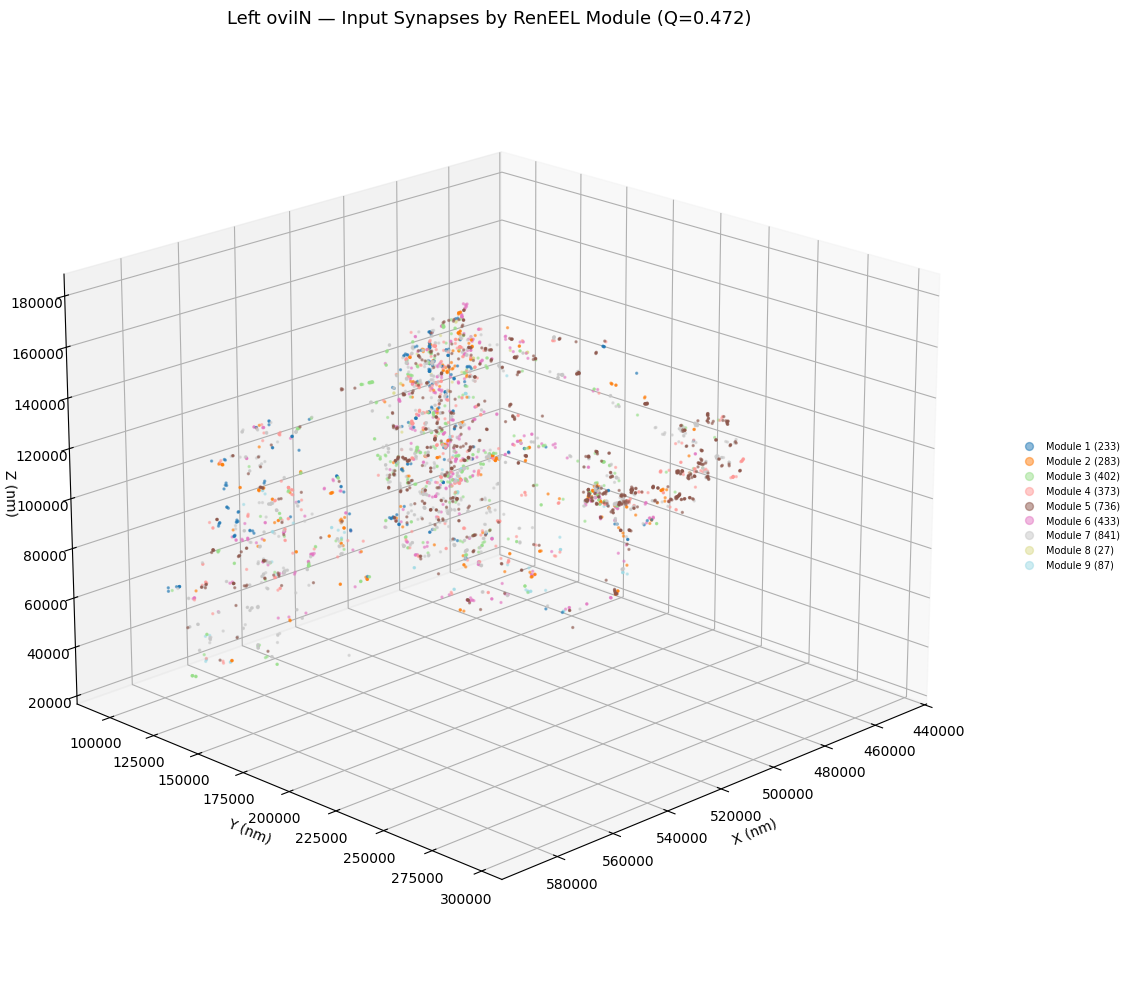

Labeled synapses: 3,415, unlabeled: 6,285


In [14]:
# ──────────────────────────────────────────────────────────
# CELL 2.6 — Skeleton plot colored by RenEEL module
# ──────────────────────────────────────────────────────────
q_str = f' (Q={reneel_q:.3f})' if reneel_q is not None else ''
fig_reneel = plot_synapses_by_group(
    ovi_syns, reneel_partition, group_col='module',
    title=f'Left oviIN — Input Synapses by RenEEL Module{q_str}',
    save_path='reneel_synapses_on_skeleton.png'
)

---
# Section 3: Degree-Corrected Stochastic Block Model

## Why Degree-Corrected SBM?

The Stochastic Block Model (SBM) takes a fundamentally different approach to community detection: instead of optimizing a score, it asks "what generative model best explains how this network was produced?" The network is assumed to have been generated by a process where each node belongs to a block, and the probability of an edge between two nodes depends only on their block memberships.

The **degree-corrected** variant (DC-SBM) additionally accounts for the fact that nodes within the same block can have different degrees — critical for connectome data where some neurons are hubs with many connections while others are sparsely connected.

The DC-SBM is the right comparison to RenEEL because:

1. **Shared assumption:** Both methods use a degree-preserving null model. RenEEL's null model redistributes edges while keeping degrees fixed; the DC-SBM explicitly includes per-node degree parameters.

2. **Different objective:** RenEEL maximizes modularity Q (a scalar score). The SBM maximizes the likelihood that the observed network was generated by the block model (equivalently, minimizes description length). Newman (2016) showed these are mathematically equivalent for the planted partition version of the DC-SBM, but in practice they use different optimization algorithms.

3. **Different optimization:** RenEEL uses spectral methods with ensemble refinement. Here, we use spectral embedding (Adjacency Spectral Embedding, ASE) to represent each node as a point in a low-dimensional space, then cluster those points using a Gaussian Mixture Model (GMM). The number of clusters is selected automatically by the Bayesian Information Criterion (BIC).

If both methods find the same communities, the structure is robust. If they disagree, the community structure may be sensitive to methodology.

## 3.1 Install graspologic and build adjacency matrix

In [19]:
# ──────────────────────────────────────────────────────────
# CELL 3.1 — Build adjacency matrix
# ──────────────────────────────────────────────────────────
from graspologic.embed import AdjacencySpectralEmbed
from graspologic.cluster import AutoGMMCluster
from scipy.sparse import csr_matrix

rows = edges_df['src'].values
cols = edges_df['tgt'].values
weights = edges_df['syn_count'].values
A = csr_matrix((weights, (rows, cols)), shape=(n_nodes, n_nodes))
A_dense = A.toarray().astype(float)

print(f"Adjacency matrix: {A.shape}, nnz: {A.nnz:,}")
print(f"Density: {A.nnz / (n_nodes * n_nodes):.4f}")

# ── Sanity check ──
assert A.shape == (n_nodes, n_nodes), "FAIL: adjacency matrix wrong shape"
n_unique_edges = edges_df.groupby(['src', 'tgt']).ngroups
assert A.nnz == n_unique_edges, f"FAIL: nnz {A.nnz} != unique edges {n_unique_edges}"
print(f"\n✓ Adjacency matrix checks passed.")

Adjacency matrix: (243, 243), nnz: 1,299
Density: 0.0220

✓ Adjacency matrix checks passed.


## 3.2 Spectral embedding

Adjacency Spectral Embedding (ASE) represents each node as a point in a low-dimensional space where nearby points have similar connectivity patterns. For directed graphs, ASE produces separate left and right embeddings (capturing outgoing and incoming connectivity respectively), which we concatenate. The number of dimensions is selected automatically by the algorithm.

In [20]:
# ──────────────────────────────────────────────────────────
# CELL 3.2 — Spectral embedding
# ──────────────────────────────────────────────────────────
ase = AdjacencySpectralEmbed(n_components=None, algorithm='randomized')
X_hat = ase.fit_transform(A_dense)

if isinstance(X_hat, tuple):
    X_embed = np.concatenate(X_hat, axis=1)
    print(f"Directed embedding: left={X_hat[0].shape}, right={X_hat[1].shape}")
    print(f"Concatenated: {X_embed.shape}")
else:
    X_embed = X_hat
    print(f"Embedding shape: {X_embed.shape}")

# ── Sanity check ──
assert X_embed.shape[0] == n_nodes, "FAIL: embedding has wrong number of rows"
assert np.isfinite(X_embed).all(), "FAIL: non-finite values in embedding"
print(f"\n✓ Embedding checks passed.")

Directed embedding: left=(243, 6), right=(243, 6)
Concatenated: (243, 12)

✓ Embedding checks passed.


## 3.3 Cluster the embedding

`AutoGMMCluster` fits Gaussian Mixture Models for a range of cluster counts (k=2 to k=max) and selects the best one using the Bayesian Information Criterion (BIC). We try multiple covariance types to avoid underfitting — the initial run found only 2 blocks, likely because the default covariance structure was too constrained for this data.

We set `min_components=2` and `max_components` to a reasonable upper bound. The algorithm explores all (k, covariance_type) combinations and returns the best.

In [22]:
# ──────────────────────────────────────────────────────────
# CELL 3.3 — Gaussian mixture clustering on the embedding
# ──────────────────────────────────────────────────────────
max_k = min(20, n_nodes // 5)
gm = AutoGMMCluster(
    min_components=2,
    max_components=max(2, max_k),
    covariance_type=['full', 'tied', 'diag', 'spherical'],
)
gm.fit(X_embed)
sbm_labels = gm.predict(X_embed)
n_blocks = len(set(sbm_labels))

print(f"DC-SBM partition: {n_blocks} blocks")
print(f"Best model: k={n_blocks}")
print(f"\nBlock sizes:")
for b, count in sorted(Counter(sbm_labels).items(), key=lambda x: -x[1]):
    print(f"  Block {b}: {count} nodes")

# ── Sanity check ──
assert n_blocks >= 2, f"FAIL: only {n_blocks} block(s) — trivial partition"
assert len(sbm_labels) == n_nodes, "FAIL: label count != node count"
print(f"\n✓ Clustering checks passed.")

DC-SBM partition: 3 blocks
Best model: k=3

Block sizes:
  Block 2: 114 nodes
  Block 1: 79 nodes
  Block 0: 50 nodes

✓ Clustering checks passed.


## 3.4 Build SBM partition DataFrame

In [23]:
# ──────────────────────────────────────────────────────────
# CELL 3.4 — Map block labels to root_ids
# ──────────────────────────────────────────────────────────
sbm_partition = pd.DataFrame({
    'node_id': range(n_nodes),
    'block': sbm_labels
})
sbm_partition['root_id'] = sbm_partition['node_id'].map(idx_to_node)

print(f"SBM partition: {sbm_partition['block'].nunique()} blocks, {len(sbm_partition)} nodes")
print(sbm_partition['block'].value_counts().sort_index())

# ── Sanity check ──
assert sbm_partition['root_id'].notna().all(), "FAIL: unmapped node_ids"
print(f"\n✓ SBM partition mapping checks passed.")

SBM partition: 3 blocks, 243 nodes
block
0     50
1     79
2    114
Name: count, dtype: int64

✓ SBM partition mapping checks passed.


## 3.5 Plot synapses — SBM blocks

Saved: sbm_synapses_on_skeleton.png


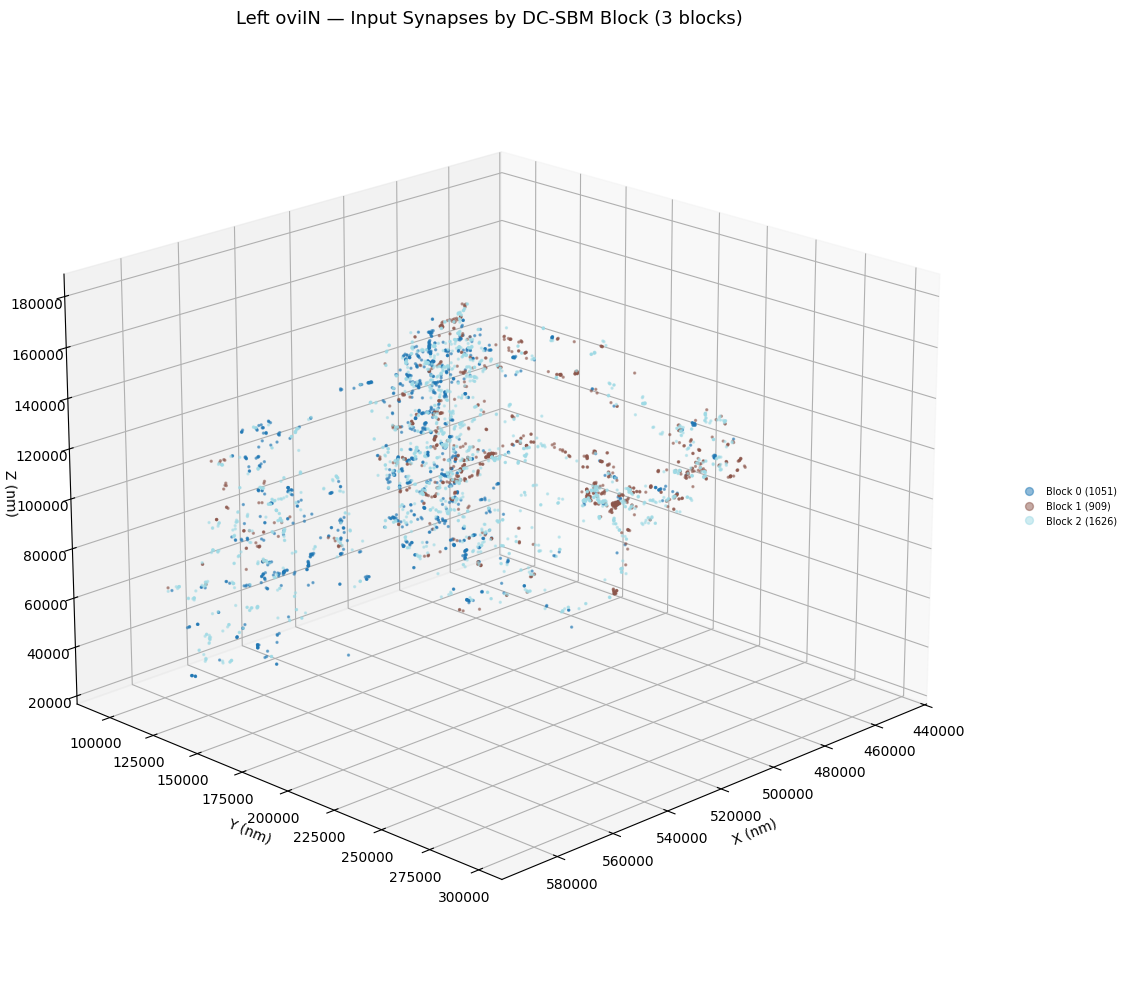

Labeled: 3,586, unlabeled: 6,114


In [24]:
# ──────────────────────────────────────────────────────────
# CELL 3.5 — Skeleton plot colored by SBM block
# ──────────────────────────────────────────────────────────
fig_sbm = plot_synapses_by_group(
    ovi_syns, sbm_partition, group_col='block',
    title=f'Left oviIN — Input Synapses by DC-SBM Block ({n_blocks} blocks)',
    save_path='sbm_synapses_on_skeleton.png'
)

---
# Section 4: Pairwise Jaccard Similarity

To quantify how much the two methods agree, we compute pairwise Jaccard similarity between every RenEEL module and every SBM block, following the approach in `jaccard_analysis.ipynb` from the oviIN-inputs repo.

The Jaccard index for two sets A and B is:

$$J(A, B) = \frac{|A \cap B|}{|A \cup B|}$$

where A is the set of neurons in a RenEEL module and B is the set of neurons in an SBM block. J = 1 means the two groups contain exactly the same neurons; J = 0 means no overlap.

If the community structure is robust, each RenEEL module should have one SBM block with high Jaccard similarity (its "best match"), and vice versa. Low best-match values across the board would suggest the two methods find fundamentally different structure.

## 4.1 Compute pairwise Jaccard

In [25]:
# ──────────────────────────────────────────────────────────
# CELL 4.1 — Pairwise Jaccard computation
# ──────────────────────────────────────────────────────────
def pairwise_jaccard(partition_a, partition_b,
                      label_a='module', label_b='block',
                      node_col='root_id'):
    """
    Pairwise Jaccard similarity between all groups in two partitions.

    Uses root_id as the shared identifier since the two partitions
    may use different internal node ID schemes.

    Returns a DataFrame: rows = partition_a groups, cols = partition_b groups.
    """
    groups_a = partition_a.groupby(label_a)[node_col].apply(set).to_dict()
    groups_b = partition_b.groupby(label_b)[node_col].apply(set).to_dict()

    keys_a = sorted(groups_a.keys())
    keys_b = sorted(groups_b.keys())

    matrix = np.zeros((len(keys_a), len(keys_b)))
    for i, ka in enumerate(keys_a):
        for j, kb in enumerate(keys_b):
            inter = len(groups_a[ka] & groups_b[kb])
            union = len(groups_a[ka] | groups_b[kb])
            matrix[i, j] = inter / union if union > 0 else 0.0

    return pd.DataFrame(matrix, index=keys_a, columns=keys_b)

jaccard = pairwise_jaccard(reneel_partition, sbm_partition)
print(f"Jaccard matrix: {jaccard.shape[0]} RenEEL modules x {jaccard.shape[1]} SBM blocks")

print(f"\nBest-match Jaccard per RenEEL module:")
for mod in jaccard.index:
    best = jaccard.loc[mod].idxmax()
    val = jaccard.loc[mod].max()
    print(f"  Module {int(mod)} -> Block {int(best)}: J = {val:.3f}")

# ── Sanity check ──
assert jaccard.shape == (n_modules, n_blocks), \
    f"FAIL: Jaccard shape {jaccard.shape} != ({n_modules}, {n_blocks})"
assert (jaccard.values >= 0).all() and (jaccard.values <= 1).all(), \
    "FAIL: Jaccard values outside [0, 1]"
print(f"\n✓ Jaccard matrix checks passed.")

Jaccard matrix: 9 RenEEL modules x 3 SBM blocks

Best-match Jaccard per RenEEL module:
  Module 1 -> Block 1: J = 0.080
  Module 2 -> Block 2: J = 0.121
  Module 3 -> Block 2: J = 0.113
  Module 4 -> Block 2: J = 0.129
  Module 5 -> Block 0: J = 0.137
  Module 6 -> Block 1: J = 0.144
  Module 7 -> Block 2: J = 0.191
  Module 8 -> Block 0: J = 0.020
  Module 9 -> Block 0: J = 0.075

✓ Jaccard matrix checks passed.


## 4.2 Jaccard heatmap

Saved: jaccard_reneel_vs_sbm.png


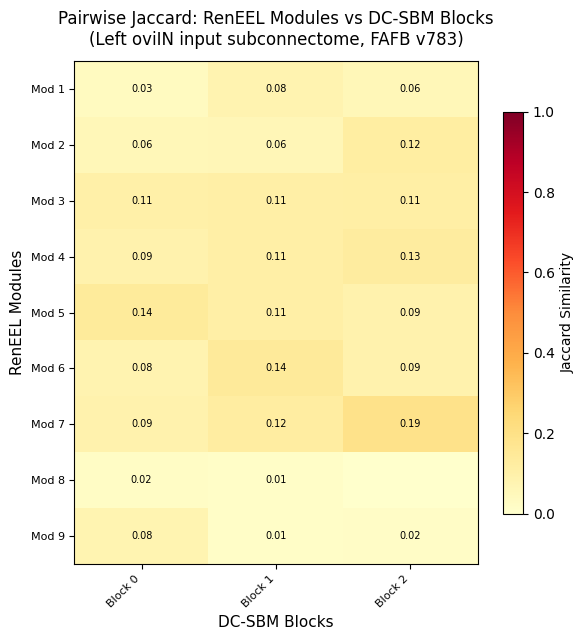

In [26]:
# ──────────────────────────────────────────────────────────
# CELL 4.2 — Jaccard heatmap
# ──────────────────────────────────────────────────────────
def plot_jaccard_heatmap(jaccard_df, title='', save_path=None):
    n_r, n_c = jaccard_df.shape
    figsize = (max(6, n_c * 0.6 + 2), max(5, n_r * 0.5 + 2))

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(jaccard_df.values, cmap='YlOrRd', aspect='auto',
                   vmin=0, vmax=1)

    ax.set_xticks(range(n_c))
    ax.set_xticklabels([f'Block {int(c)}' for c in jaccard_df.columns],
                       rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(n_r))
    ax.set_yticklabels([f'Mod {int(r)}' for r in jaccard_df.index], fontsize=8)

    ax.set_xlabel('DC-SBM Blocks', fontsize=11)
    ax.set_ylabel('RenEEL Modules', fontsize=11)

    for i in range(n_r):
        for j in range(n_c):
            val = jaccard_df.values[i, j]
            if val > 0.01:
                color = 'white' if val > 0.5 else 'black'
                ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                        fontsize=7, color=color)

    cbar = fig.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label('Jaccard Similarity', fontsize=10)

    if title:
        ax.set_title(title, fontsize=12, pad=12)
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()
    return fig

fig_jaccard = plot_jaccard_heatmap(
    jaccard,
    title='Pairwise Jaccard: RenEEL Modules vs DC-SBM Blocks\n(Left oviIN input subconnectome, FAFB v783)',
    save_path='jaccard_reneel_vs_sbm.png'
)

## 4.3 Summary

In [27]:
# ──────────────────────────────────────────────────────────
# CELL 4.3 — Comparison summary
# ──────────────────────────────────────────────────────────
print("=" * 65)
print("COMPARISON SUMMARY")
print("=" * 65)
print(f"\nDataset: FAFB FlyWire v783")
print(f"Target: left oviIN (root_id {oviIN_left_id})")
print(f"Subconnectome: {n_nodes} input neurons, {len(edges_df):,} directed edges")

print(f"\n--- RenEEL (chi=0, degree-preserving null model) ---")
print(f"  Modules: {reneel_partition['module'].nunique()}")
print(f"  Q value: {reneel_q:.4f}")
print(f"  Nodes assigned: {len(reneel_partition)} / {n_nodes}")

print(f"\n--- DC-SBM (spectral embedding + GMM, BIC model selection) ---")
print(f"  Blocks: {sbm_partition['block'].nunique()}")
print(f"  Nodes assigned: {len(sbm_partition)} / {n_nodes}")

print(f"\n--- Pairwise Jaccard ---")
print(f"  Mean best-match (per module): {jaccard.max(axis=1).mean():.3f}")
print(f"  Mean best-match (per block):  {jaccard.max(axis=0).mean():.3f}")
print(f"  Max Jaccard: {jaccard.values.max():.3f}")
print(f"  Pairs with J > 0.5: {(jaccard.values > 0.5).sum()}")
print("=" * 65)

COMPARISON SUMMARY

Dataset: FAFB FlyWire v783
Target: left oviIN (root_id 720575940628360506)
Subconnectome: 243 input neurons, 2,542 directed edges

--- RenEEL (chi=0, degree-preserving null model) ---
  Modules: 9
  Q value: 0.4721
  Nodes assigned: 232 / 243

--- DC-SBM (spectral embedding + GMM, BIC model selection) ---
  Blocks: 3
  Nodes assigned: 243 / 243

--- Pairwise Jaccard ---
  Mean best-match (per module): 0.112
  Mean best-match (per block):  0.157
  Max Jaccard: 0.191
  Pairs with J > 0.5: 0


## Interpretation

High mean best-match Jaccard (close to 1.0) would indicate that both methods converge on the same communities — evidence that the structure is a robust property of the network, not an artifact of the detection algorithm.

Low Jaccard values could mean several things: the methods genuinely disagree about the community structure (the partition is method-dependent), the methods are finding structure at different scales (e.g., RenEEL subdivides into 9 modules while the SBM finds only 2 or 3 coarser blocks), or one method is underfitting. The number of communities found by each method and the spatial coherence of the skeleton plots help distinguish between these possibilities.

Since RenEEL and the DC-SBM share a degree-preserving null model, differences are attributable to the optimization procedure (spectral ensemble refinement vs spectral embedding + GMM) and the model selection criterion (modularity Q vs BIC). If the underlying community structure is strong, both should converge on similar partitions regardless of how they search for them.

---
# Section 5: Pipeline Module

This section demonstrates the same analysis using `modularity_sbm_pipeline.py`, the standalone Python module that packages all the functions from this notebook for reuse. This is the pattern used in the lab's other analysis notebooks (e.g., `primacy_pipeline.py`) — develop step-by-step in the notebook, then call the packaged functions for production use.

In [28]:
# ──────────────────────────────────────────────────────────
# CELL 5.1 — Upload and import the pipeline module
# ──────────────────────────────────────────────────────────
# Option A: Upload modularity_sbm_pipeline.py to /content via the Colab file browser
# Option B: Download from Drive or GitHub
# Once the file is at /content/modularity_sbm_pipeline.py:

import sys
sys.path.insert(0, '/content')

from modularity_sbm_pipeline import (
    extract_input_subconnectome,
    build_integer_edge_list,
    symmetrize_edge_list,
    fit_dcsbm_spectral,
    pairwise_jaccard,
    plot_synapses_by_group,
    plot_jaccard_heatmap,
)
print("Pipeline module imported.")

Pipeline module imported.


Inputs: 243, Edges: 2,542
Nodes: 243, Edges: 2,542
Adjacency matrix: (243, 243), nnz: 1,299
Directed embedding: 6+6 dims
DC-SBM: 2 blocks

SBM blocks: 2

Jaccard matrix: (9, 2)
Mean best-match (per module): 0.108
Saved: pipeline_jaccard.png


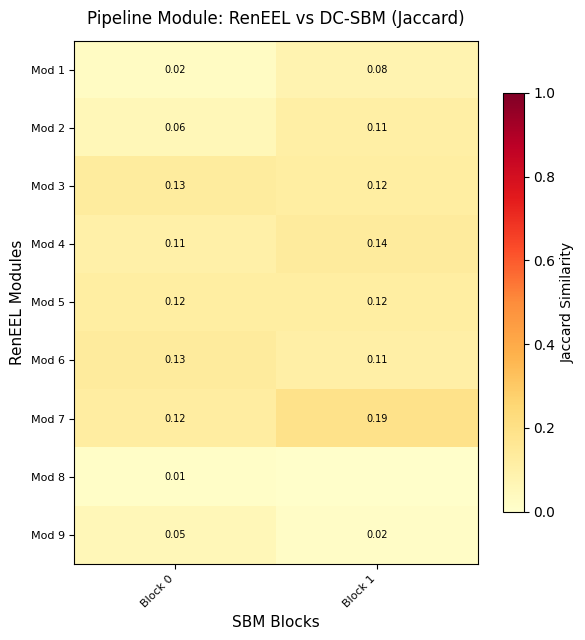

In [29]:
# ──────────────────────────────────────────────────────────
# CELL 5.2 — Run the full pipeline via module functions
# ──────────────────────────────────────────────────────────

# Step 1: Extract subconnectome
input_ids_pipe, subconn_pipe = extract_input_subconnectome(
    connections, oviIN_left_id
)
print(f"Inputs: {len(input_ids_pipe)}, Edges: {len(subconn_pipe):,}")

# Step 2: Build integer edge list
edges_pipe, n2i_pipe, i2n_pipe = build_integer_edge_list(
    subconn_pipe, input_ids_pipe
)
n_pipe = len(input_ids_pipe)
print(f"Nodes: {n_pipe}, Edges: {len(edges_pipe):,}")

# Step 3: Fit DC-SBM
sbm_pipe = fit_dcsbm_spectral(
    edges_pipe, n_pipe, idx_to_node=i2n_pipe, max_components=20
)
print(f"\nSBM blocks: {sbm_pipe['block'].nunique()}")

# Step 4: Compute Jaccard (comparing against RenEEL from Section 2)
jac_pipe = pairwise_jaccard(reneel_partition, sbm_pipe)
print(f"\nJaccard matrix: {jac_pipe.shape}")
print(f"Mean best-match (per module): {jac_pipe.max(axis=1).mean():.3f}")

# Step 5: Plot
fig = plot_jaccard_heatmap(
    jac_pipe,
    title='Pipeline Module: RenEEL vs DC-SBM (Jaccard)',
    save_path='pipeline_jaccard.png'
)

### Sanity check: pipeline vs notebook results

The pipeline module functions should produce identical results to the step-by-step notebook cells. We verify this by checking that the subconnectome extraction gives the same number of nodes and edges, and that the Jaccard computation on the same partitions gives the same matrix.

In [30]:
# ──────────────────────────────────────────────────────────
# CELL 5.3 — Verify pipeline matches notebook
# ──────────────────────────────────────────────────────────
assert input_ids_pipe == input_ids, \
    f"FAIL: input_ids differ ({len(input_ids_pipe)} vs {len(input_ids)})"
assert len(subconn_pipe) == len(subconn), \
    f"FAIL: subconn edge counts differ ({len(subconn_pipe)} vs {len(subconn)})"
assert len(edges_pipe) == len(edges_df), \
    f"FAIL: edge list sizes differ ({len(edges_pipe)} vs {len(edges_df)})"

print(f"✓ Subconnectome extraction matches: {len(input_ids)} nodes, {len(subconn):,} edges")
print(f"✓ Edge list matches: {len(edges_df):,} directed edges")
print(f"\n✓ Pipeline module produces consistent results.")

✓ Subconnectome extraction matches: 243 nodes, 2,542 edges
✓ Edge list matches: 2,542 directed edges

✓ Pipeline module produces consistent results.
